# ***Flujo del proyecto***
1. Comprensión del negocio
2. Análisis exploratorio de los datos (EDA)
3. Preprocesamiento: Limpieza, calidad e ingeniería de carácteristicas
4. Entrenamiento de los modelos: Cuantos? Cuáles? --> Depende de las métricas
5. Evaluación: Comparar métricas
6. Modelo final y conclusiones

## **1. Comprensión del negocio**



### **Contexto del Problema**
La accidentalidad vial en Colombia, y específicamente en departamentos con alta densidad vehicular como Antioquia, representa un problema crítico de salud pública y de gestión de recursos estatales. Sin embargo, en este ámbito, la calidad de la información recopilada por los agentes de tránsito suele ser inconsistente, presentando valores nulos, errores de digitación y formatos incorrectos. Por lo tanto, antes de poder generar cualquier modelo de inteligencia artificial sobre estos datos, es un requisito técnico indispensable aplicar procesos de Data Cleaning para garantizar la calidad y confiabilidad de la información.

### **Formulación de Preguntas de Negocio**

**Pregunta Descriptiva**
- Cuáles son los patrones de accidentalidad más recurrentes en Antioquia según la clase de accidente (choque, volcamiento) y la hora del día, variables que presentan la mayor confiabilidad en el dataset?


**Pregunta Predictiva (Enfoque en Machine Learning)**
- ¿Qué nivel de precisión podemos alcanzar al predecir la gravedad de un siniestro vial utilizando algoritmos de clasificación?



## **2.Análisis exploratorio de los datos (EDA)**

### **Importación de las librerías**

In [1]:
import pandas as pd
#from google.colab import drive
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

### **Configuración de los gráficos**

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
    'axes.labelsize': 14,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'legend.frameon': True,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
})

### **Carga del Dataset**

In [3]:
WEB_URL = 'https://www.datos.gov.co/resource/xpyu-s4ma.csv'
LOCAL_PATH = '/content/drive/MyDrive/Aprendizaje de máquinas/accidentes_antioquia.csv'

In [4]:
USE_LOCAL_DATA = False

In [5]:
if USE_LOCAL_DATA:
    try:
        print("Buscando datos en Google Drive...")
        drive.mount('/content/drive')
        df = pd.read_csv(LOCAL_PATH)
        print("Datos locales cargados con éxito.")
    except FileNotFoundError:
        print("No se encontró el archivo en la ruta local.")
        print("Descargando desde la web como respaldo...")
        df = pd.read_csv(WEB_URL)
        print("Datos web cargados con éxito.")
else:
    print("Descargando datos directamente desde la web...")
    df = pd.read_csv(WEB_URL)
    print("Datos web cargados con éxito.")

Descargando datos directamente desde la web...
Datos web cargados con éxito.


In [6]:
df

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
0,2014-11-04T00:00:00.000Z,06:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,AMAGA,KM 2,0,0,0,0,0,0
1,2015-05-17T00:00:00.000Z,11:05,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,URBANA,...,TRAMO DE VÍA,NORMAL,AMAGA,CALLE 47 49 64,0,0,0,0,0,0
2,2014-06-11T00:00:00.000Z,12:01,h,VOLCAMIENTO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,PEND. NOTIFICACIÓN,URBANA,...,TRAMO DE VÍA,NORMAL,NO REPORTA,CALLE 20 CON CARRERA 20,0,0,0,0,0,0
3,2014-03-09T00:00:00.000Z,09:01,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,TRONCAL DEL CAFÉ SECTOR EL LICEO,0,0,0,0,0,0
4,2014-04-28T00:00:00.000Z,21:01,h,CAÍDA OCUPANTE,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,VEREDA LA CLARITA,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,2022-07-17T00:00:00.000Z,04:07,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Lluvia,ANTIOQUIA,LLANOS -TARZAN KM 76+550,0,0,1,0,1,0
842,2022-06-02T00:00:00.000Z,12:06,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VIA SABANALARGA- CORREGIMIEMNTO EL ORO KILOMET...,0,0,0,2,2,0
843,2022-03-20T00:00:00.000Z,13:03,h,ATROPELLO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VEREDA EL CAIRO,0,0,1,0,1,0
844,2022-01-21T00:00:00.000Z,16:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ABEJORRAL,VIA ABEJORRAL - MESOPOTAMIA,0,0,1,1,2,0


### **Inspección de Datos**



In [7]:
print("Dataset: Accidentes de tránsito en Antioquia")
print(f'Muestras: {df.shape[0]}')
print(f'Características: {df.shape[1]}')
print(f'Descripción del dataset: {df.info()}')

Dataset: Accidentes de tránsito en Antioquia
Muestras: 846
Características: 21
<class 'pandas.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   fecha_accidente             846 non-null    str  
 1   hora_accidente              846 non-null    str  
 2   gravedad                    846 non-null    str  
 3   clase_accidente             846 non-null    str  
 4   causante_accidente          846 non-null    str  
 5   descripcion_colisionante    846 non-null    str  
 6   descripcion_objeto_fijo     846 non-null    str  
 7   zona_accidente              846 non-null    str  
 8   descripcion_de_estado       846 non-null    str  
 9   area_accidente              846 non-null    str  
 10  sector_accidente            846 non-null    str  
 11  descripcion_localizacion    846 non-null    str  
 12  estado_clima                846 non-null    str  
 1

- *846 filas*
- *21 Columnas*
- *Todos los campos con 846 non-null*
- *Tipos de datos de texto y numéricos*

*Muestra variables numéricas*




In [8]:
df.describe()

,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,0.068558,0.022459,0.166667,0.308511,0.500000,0.068558
std,0.275259,0.190214,1.097334,0.533470,1.163295,0.299948
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,2.000000,3.000000,25.000000,2.000000,23.000000,3.000000


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
numero_victima_peaton,846.0,0.068558,0.275259,0.0,0.0,0.0,0.0,2.0
numero_victima_acompanante,846.0,0.022459,0.190214,0.0,0.0,0.0,0.0,3.0
numero_victima_pasajero,846.0,0.166667,1.097334,0.0,0.0,0.0,0.0,25.0
numero_victima_conductor,846.0,0.308511,0.533470,0.0,0.0,0.0,1.0,2.0
numero_victima_herido,846.0,0.500000,1.163295,0.0,0.0,0.0,1.0,23.0
numero_victima_muerto,846.0,0.068558,0.299948,0.0,0.0,0.0,0.0,3.0


*Muestra todas las variables*




In [11]:
df.describe(include='all').round(3).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha_accidente,846,649,2014-05-18T00:00:00.000Z,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hora_accidente,846,214,16:01,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gravedad,846,3,h,444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clase_accidente,846,7,CHOQUE,638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
causante_accidente,846,2,Ciclista-Motociclista,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion_colisionante,846,5,VEHÍCULO,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion_objeto_fijo,846,9,NO REPORTADO,779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona_accidente,846,8,NO REPORTADO,832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion_de_estado,846,7,PEND. NOTIFICACIÓN,428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_accidente,846,5,RURAL,475,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.describe(include='all').round(3)

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
count,846,846,846,846,846,846,846,846,846,846,...,846,846,846,846,846.000,846.000,846.000,846.000,846.000,846.000
unique,649,214,3,7,2,5,9,8,7,5,...,13,5,35,801,NaN,NaN,NaN,NaN,NaN,NaN
top,2014-05-18T00:00:00.000Z,16:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,PEND. NOTIFICACIÓN,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,VEREDA PIEDRAS BLANCAS,NaN,NaN,NaN,NaN,NaN,NaN
freq,4,30,444,638,843,558,779,832,428,475,...,718,720,359,5,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.069,0.022,0.167,0.309,0.500,0.069
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.275,0.190,1.097,0.533,1.163,0.300
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,1.000,1.000,0.000


*Muestra de Datos*


In [14]:
df.head()

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
0,2014-11-04T00:00:00.000Z,06:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,AMAGA,KM 2,0,0,0,0,0,0
1,2015-05-17T00:00:00.000Z,11:05,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,URBANA,...,TRAMO DE VÍA,NORMAL,AMAGA,CALLE 47 49 64,0,0,0,0,0,0
2,2014-06-11T00:00:00.000Z,12:01,h,VOLCAMIENTO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,PEND. NOTIFICACIÓN,URBANA,...,TRAMO DE VÍA,NORMAL,NO REPORTA,CALLE 20 CON CARRERA 20,0,0,0,0,0,0
3,2014-03-09T00:00:00.000Z,09:01,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,TRONCAL DEL CAFÉ SECTOR EL LICEO,0,0,0,0,0,0
4,2014-04-28T00:00:00.000Z,21:01,h,CAÍDA OCUPANTE,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,VEREDA LA CLARITA,0,0,0,0,0,0


In [15]:
df.tail()

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
841,2022-07-17T00:00:00.000Z,04:07,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Lluvia,ANTIOQUIA,LLANOS -TARZAN KM 76+550,0,0,1,0,1,0
842,2022-06-02T00:00:00.000Z,12:06,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VIA SABANALARGA- CORREGIMIEMNTO EL ORO KILOMET...,0,0,0,2,2,0
843,2022-03-20T00:00:00.000Z,13:03,h,ATROPELLO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VEREDA EL CAIRO,0,0,1,0,1,0
844,2022-01-21T00:00:00.000Z,16:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ABEJORRAL,VIA ABEJORRAL - MESOPOTAMIA,0,0,1,1,2,0
845,2022-05-28T00:00:00.000Z,18:05,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ABEJORRAL,VIA ABEJORRAL - LA CEJA KM 15+200,0,0,0,0,0,0


In [16]:
df.sample()

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
535,2014-12-20T00:00:00.000Z,08:12,m,ATROPELLO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,PEND. NOTIFICACIÓN,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,VÍA A MINAS VEREDA NICANOR,0,0,0,1,0,1


**Top no reportado**
- **Objeto fijo** 779
- **Zona accidente** 832

**Unique**
- **Dirección** 801

### **Calidad de los Datos**

In [17]:
print(df.isna().sum().to_string())

fecha_accidente               0
hora_accidente                0
gravedad                      0
clase_accidente               0
causante_accidente            0
descripcion_colisionante      0
descripcion_objeto_fijo       0
zona_accidente                0
descripcion_de_estado         0
area_accidente                0
sector_accidente              0
descripcion_localizacion      0
estado_clima                  0
municipio                     0
direccion_lugar               0
numero_victima_peaton         0
numero_victima_acompanante    0
numero_victima_pasajero       0
numero_victima_conductor      0
numero_victima_herido         0
numero_victima_muerto         0


In [18]:
print(df.isnull().sum().to_string())

fecha_accidente               0
hora_accidente                0
gravedad                      0
clase_accidente               0
causante_accidente            0
descripcion_colisionante      0
descripcion_objeto_fijo       0
zona_accidente                0
descripcion_de_estado         0
area_accidente                0
sector_accidente              0
descripcion_localizacion      0
estado_clima                  0
municipio                     0
direccion_lugar               0
numero_victima_peaton         0
numero_victima_acompanante    0
numero_victima_pasajero       0
numero_victima_conductor      0
numero_victima_herido         0
numero_victima_muerto         0


In [19]:
df.select_dtypes(include=['object']).nunique()

fecha_accidente             649
hora_accidente              214
gravedad                      3
clase_accidente               7
causante_accidente            2
descripcion_colisionante      5
descripcion_objeto_fijo       9
zona_accidente                8
descripcion_de_estado         7
area_accidente                5
sector_accidente              8
descripcion_localizacion     13
estado_clima                  5
municipio                    35
direccion_lugar             801
dtype: int64

In [20]:
df['clase_accidente'].value_counts()

clase_accidente
CHOQUE            638
ATROPELLO          87
VOLCAMIENTO        68
CAÍDA OCUPANTE     30
OTRO               19
INCENDIO            3
NO REPORTADA        1
Name: count, dtype: int64

In [21]:
df['descripcion_de_estado'].value_counts()

descripcion_de_estado
PEND. NOTIFICACIÓN    428
FALLADO               303
PEND. DECLARACIÓN      46
Pend. Notificación     43
CONCILIADO             16
Pend. Declaración       7
PEND. FALLO             3
Name: count, dtype: int64

In [23]:
df['gravedad'].value_counts()

gravedad
h    444
d    342
m     60
Name: count, dtype: int64

In [25]:
df['causante_accidente'].value_counts()

causante_accidente
Ciclista-Motociclista    843
Conductor                  3
Name: count, dtype: int64

In [27]:
df['descripcion_colisionante'].value_counts()

descripcion_colisionante
VEHÍCULO        558
NO REPORTADO    208
OBJETO FIJO      67
SEMOVIENTE       11
Semoviente        2
Name: count, dtype: int64

In [28]:
df['descripcion_objeto_fijo'].value_counts()

descripcion_objeto_fijo
NO REPORTADO            779
ÁRBOL                    14
OTRO                     11
MURO                     11
POSTE                    10
VEHÍCULO ESTACIONADO      9
BARANDA                   7
INMUEBLE                  4
VALLA, SEÑAL              1
Name: count, dtype: int64

In [29]:
df['zona_accidente'].value_counts()

zona_accidente
NO REPORTADO    832
ESCOLAR           5
DEPORTIVA         2
PRIVADA           2
Escolar           2
MILITAR           1
HOSPITALARIA      1
TURÍSTICA         1
Name: count, dtype: int64

In [31]:
df['area_accidente'].value_counts()

area_accidente
RURAL           475
URBANA          320
Rural            37
Urbana           13
NO REPORTADO      1
Name: count, dtype: int64

In [32]:
df['sector_accidente'].value_counts()

sector_accidente
NO REPORTADO    477
RESIDENCIAL     238
COMERCIAL        68
No Reportado     37
INDUSTRIAL       13
Residencial       8
Comercial         4
Industrial        1
Name: count, dtype: int64

In [33]:
df['descripcion_localizacion'].value_counts()

descripcion_localizacion
TRAMO DE VÍA     718
INTERSECCIÓN      52
Tramo de via      48
PUENTE             8
LOTE O PREDIO      7
PASO INFERIOR      2
PASO A NIVEL       2
GLORIETA           2
PASO ELEVADO       2
Interseccion       2
NO REPORTADO       1
VÍA PEATONAL       1
VÍA TRONCAL        1
Name: count, dtype: int64

In [34]:
df['estado_clima'].value_counts()

estado_clima
NORMAL    720
LLUVIA     71
Normal     43
Lluvia      7
NIEBLA      5
Name: count, dtype: int64

### **Valores no reportados**

In [18]:
# Conteo de valores "NO REPORTADO" o similares por columna
print("--- Cantidad de datos 'No Reportados' por columna ---")
for col in df.columns:
    # Contar cuántas veces aparece la frase (ignorando mayúsculas/minúsculas)
    no_reportados = df[col].astype(str).str.upper().str.contains('NO REPORTA').sum()
    if no_reportados > 0:
        porcentaje = (no_reportados / len(df)) * 100
        print(f"{col}: {no_reportados} registros ({porcentaje:.1f}%)")

--- Cantidad de datos 'No Reportados' por columna ---
clase_accidente: 1 registros (0.1%)
descripcion_colisionante: 208 registros (24.6%)
descripcion_objeto_fijo: 779 registros (92.1%)
zona_accidente: 832 registros (98.3%)
area_accidente: 1 registros (0.1%)
sector_accidente: 514 registros (60.8%)
descripcion_localizacion: 1 registros (0.1%)
municipio: 359 registros (42.4%)


*Dado que un modelo de Machine Learning no puede aprender patrones de valores inexistentes ('No Reportado'), tomamos la decisión técnica de eliminar por completo (Drop) las columnas zona_accidente (98.3%), descripcion_objeto_fijo (92.1%)*

### **Gráfico de barras y diagrama de torta- Analizando distribución de la gravedad**

  *Nota: En la página de la secretaría se encuentra la info: GRAVEDAD
  Es la gravedad del accidente (Opciones: M: con muertos, H:con heridos, D: solo daños)*

Text(0.5, 1.0, 'Porcentaje de muestras por clase')

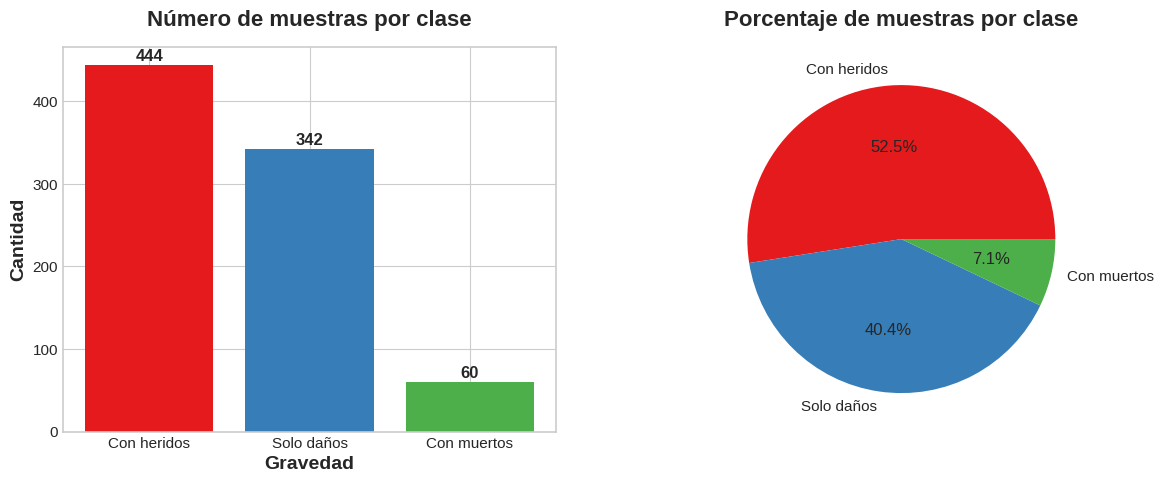

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

diccionario_gravedad = {
    'h': 'Con heridos',
    'd': 'Solo daños',
    'm': 'Con muertos'
}
df['gravedad'] = df['gravedad'].replace(diccionario_gravedad)

# Gráfico de Barras
class_counts = df['gravedad'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('Set1', 3))
axes[0].set_title('Número de muestras por clase', fontweight='bold')
axes[0].set_xlabel('Gravedad')
axes[0].set_ylabel('Cantidad')


for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 5, int(height), ha='center', fontweight='bold')

# Grafico de pastel
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set1', len(class_counts)))
axes[1].set_title('Porcentaje de muestras por clase', fontweight='bold')

*Desbalanceado*

###**Gráfico de barras Distribución de clase accidente**

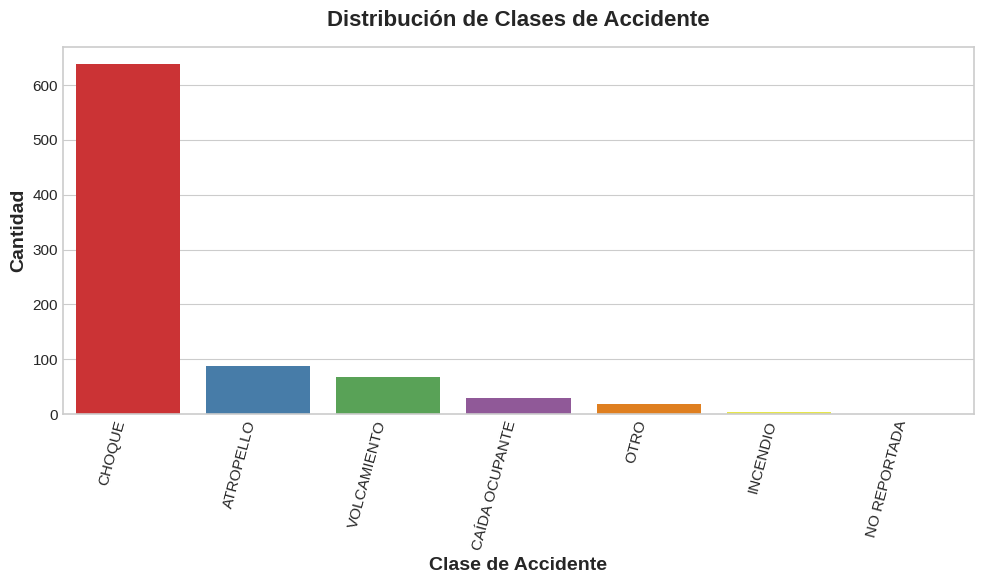

In [20]:
plt.figure(figsize=(10, 6))

# ordenar las barras de mayor a menor para mejor lectura
orden = df['clase_accidente'].value_counts().index
sns.countplot(data=df, x='clase_accidente', order=orden, palette='Set1')

plt.title('Distribución de Clases de Accidente', fontweight='bold')
plt.xlabel('Clase de Accidente')
plt.ylabel('Cantidad')

# Rotar las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=75, ha='right')

# Asegura que nada se corte en los bordes
plt.tight_layout()
plt.show()

### **Gráfico histogrma distribución de hora**



In [21]:
#Hora entera
df['hora_entera'] = df['hora_accidente'].astype(str).str.split(':').str[0]

# Convertimos a numérico, forzando errores a NaN, llenando con 0 y pasando a entero
df['hora_entera'] = pd.to_numeric(df['hora_entera'], errors='coerce').fillna(0).astype(int)


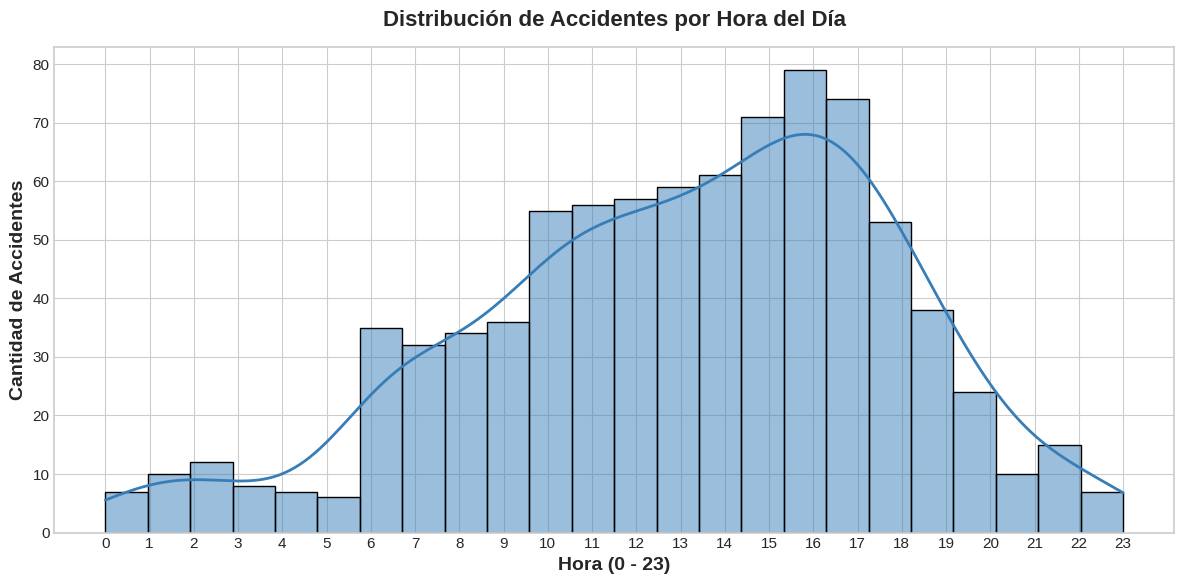

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# Usa histplot de Seaborn con la curva de densidad (KDE)
sns.histplot(data=df, x='hora_entera', bins=24, kde=True, color=sns.color_palette("Set1")[1], ax=axes)

axes.set_title('Distribución de Accidentes por Hora del Día', fontweight='bold')
axes.set_xlabel('Hora (0 - 23)', fontweight='bold')
axes.set_ylabel('Cantidad de Accidentes', fontweight='bold')

# el eje X muestra todas las horas del día de 0 a 23
axes.set_xticks(np.arange(0, 24, 1))

plt.tight_layout()
plt.show()

##**3 Preprocesamiento: Limpieza, calidad e ingeniería de carácteristicas**.


### **Eliminación de variables no reportadas**


In [23]:
variables_eliminar= [
    'zona_accidente',
    'descripcion_objeto_fijo',
    'direccion_lugar', 'fecha_accidente', 'hora_accidente','sector_accidente'
]

df_prep= df.drop(variables_eliminar, axis=1)
df_prep


,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_de_estado,area_accidente,descripcion_localizacion,estado_clima,municipio,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto,hora_entera
0,Con heridos,CHOQUE,Ciclista-Motociclista,VEHÍCULO,FALLADO,RURAL,TRAMO DE VÍA,NORMAL,AMAGA,0,0,0,0,0,0,6
1,Solo daños,CHOQUE,Ciclista-Motociclista,VEHÍCULO,FALLADO,URBANA,TRAMO DE VÍA,NORMAL,AMAGA,0,0,0,0,0,0,11
2,Con heridos,VOLCAMIENTO,Ciclista-Motociclista,NO REPORTADO,PEND. NOTIFICACIÓN,URBANA,TRAMO DE VÍA,NORMAL,NO REPORTA,0,0,0,0,0,0,12
3,Solo daños,CHOQUE,Ciclista-Motociclista,VEHÍCULO,FALLADO,RURAL,TRAMO DE VÍA,NORMAL,NO REPORTA,0,0,0,0,0,0,9
4,Con heridos,CAÍDA OCUPANTE,Ciclista-Motociclista,NO REPORTADO,FALLADO,RURAL,TRAMO DE VÍA,NORMAL,NO REPORTA,0,0,0,0,0,0,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,Con heridos,CHOQUE,Ciclista-Motociclista,VEHÍCULO,Pend. Notificación,Rural,Tramo de via,Lluvia,ANTIOQUIA,0,0,1,0,1,0,4
842,Con heridos,CHOQUE,Ciclista-Motociclista,VEHÍCULO,Pend. Notificación,Rural,Tramo de via,Normal,ANTIOQUIA,0,0,0,2,2,0,12
843,Con heridos,ATROPELLO,Ciclista-Motociclista,NO REPORTADO,Pend. Notificación,Rural,Tramo de via,Normal,ANTIOQUIA,0,0,1,0,1,0,13
844,Con heridos,CHOQUE,Ciclista-Motociclista,VEHÍCULO,Pend. Notificación,Rural,Tramo de via,Normal,ABEJORRAL,0,0,1,1,2,0,16


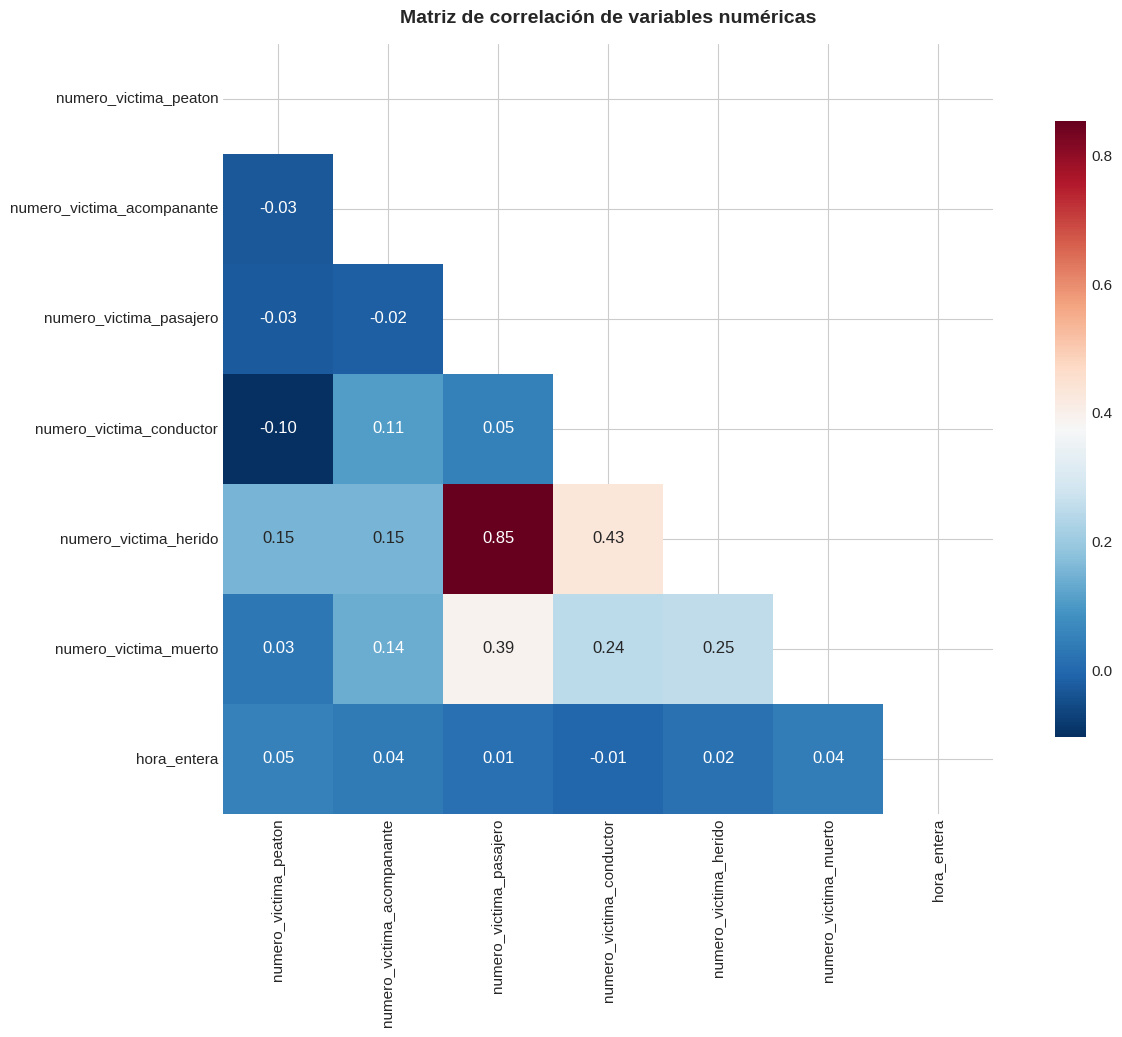

In [24]:
fig, ax = plt.subplots(figsize=(16, 10))

# 2. Se filtran solo las variables numéricas para calcular la correlación
df_numerico = df.select_dtypes(include=['int64', 'float64'])
correlacion = df_numerico.corr()

# 3. Creación de la máscara para ocultar el triángulo superior
mask = np.triu(np.ones_like(correlacion, dtype=bool))

# 4. Generación del mapa de calor con los estilos solicitados
sns.heatmap(correlacion,
            annot=True,
            mask=mask,
            fmt='.2f',
            cmap='RdBu_r',
            ax=ax,
            cbar_kws={'shrink': 0.8},
            square=True)

# 5. Configuración del título
ax.set_title('Matriz de correlación de variables numéricas', fontweight='bold', fontsize=14)

plt.show()

### **Encoding**

In [25]:
le = preprocessing.LabelEncoder()
le.fit(df_prep['gravedad'])

LabelEncoder()

In [26]:
print("Clases aprendidas por el LabelEncoder (le.classes_):")
print(le.classes_)



Clases aprendidas por el LabelEncoder (le.classes_):
['Con heridos' 'Con muertos' 'Solo daños']


In [27]:
df_prep['gravedad'] = le.transform(df_prep['gravedad'])

In [28]:
print("Antes del encoding, la columna 'clase_accidente' se ve así:")
print(df_prep['clase_accidente'].head(3))

Antes del encoding, la columna 'clase_accidente' se ve así:
0         CHOQUE
1         CHOQUE
2    VOLCAMIENTO
Name: clase_accidente, dtype: object


In [29]:
df_prep = pd.get_dummies(df_prep, columns=['clase_accidente'], drop_first=True)

In [30]:
print("\nDespués del encoding, se crearon nuevas columnas con valores booleanos (0 y 1):")
# Filtramos solo las columnas nuevas que empiezan por 'clase_accidente_' para mostrarlas
columnas_nuevas = [col for col in df_prep.columns if 'clase_accidente_' in col]
print(df_prep[columnas_nuevas].head(3))


Después del encoding, se crearon nuevas columnas con valores booleanos (0 y 1):
   clase_accidente_CAÍDA OCUPANTE  clase_accidente_CHOQUE  \
0                           False                    True   
1                           False                    True   
2                           False                   False   

   clase_accidente_INCENDIO  clase_accidente_NO REPORTADA  \
0                     False                         False   
1                     False                         False   
2                     False                         False   

   clase_accidente_OTRO  clase_accidente_VOLCAMIENTO  
0                 False                        False  
1                 False                        False  
2                 False                         True  
